# Final project: Intelligent Medical Image Classification

Team members: LMV N1

*   Rocío Sánchez Solórzano 2043109
*   Karen Melissa Morales Moya 2043909
*   Hugo Fernando Nuncio Álvarez 2104134
*   Juan Gerardo Torres Flores 2074382

**Pneumonia Detection from Chest X-Ray Images using CNN**

This notebook trains a convolutional neural network to classify chest X-ray images as either NORMAL or PNEUMONIA.

*Dataset: Kaggle - Chest X-Ray Images Pneumonia*

In [24]:
#import required libraries
import os
import zipfile
import numpy as np
from PIL import Image
import tensorflow as tf
from google.colab import files
import matplotlib.pyplot as plt

from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing import image as keras_image
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [25]:
#kaggle setup
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [26]:
#download and extract dataset
dataset_name = 'paultimothymooney/chest-xray-pneumonia'
zip_file = 'chest-xray-pneumonia.zip'

!kaggle datasets download -d {dataset_name}

with zipfile.ZipFile(zip_file,'r') as zip_ref:
    zip_ref.extractall('./dataset')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [28]:
#define dataset paths and parameters
base_path = './dataset/chest_xray'
train_path = os.path.join(base_path,'train')
test_path = os.path.join(base_path,'test')

image_size = (150,150)
batch_size = 32
validation_split = .2
seed = 123

In [29]:
#data cleaning
def clean_dataset(directory):
    bad_files = []
    for root,dirs,files in os.walk(directory):
        for file1 in files:
            path = os.path.join(root,file1)
            try:
                with Image.open(path) as img:
                    img.verify()
            except:
                bad_files.append(path)
    print(f'corrupted images found: {len(bad_files)}')

clean_dataset(train_path)
clean_dataset(test_path)

corrupted images found: 0
corrupted images found: 0


In [30]:
#load images into TensorFlow datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=validation_split,
    subset='training',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='binary')

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=validation_split,
    subset='validation',
    seed=seed,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='binary')

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='binary')

class_names = train_ds.class_names
print('classes:',class_names)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.
classes: ['NORMAL', 'PNEUMONIA']


In [31]:
#improve dataset performance
autotune = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=autotune)
val_ds = val_ds.cache().prefetch(buffer_size=autotune)
test_ds = test_ds.cache().prefetch(buffer_size=autotune)

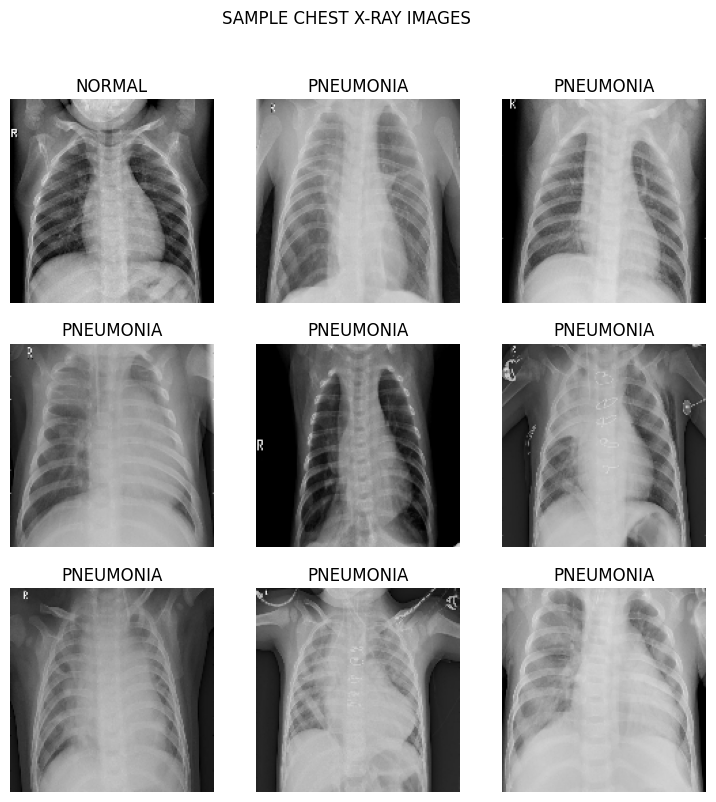

In [32]:
#display sample images
plt.figure(figsize=(9,9))

for images, labels in train_ds.take(1):
    for index in range(9):
        plt.subplot(3,3,index+1)
        plt.imshow(images[index].numpy().astype('uint8'))
        label_index = int(labels[index].numpy()[0])
        plt.title(class_names[label_index])
        plt.axis('off')

plt.suptitle('SAMPLE CHEST X-RAY IMAGES')
plt.show()

In [33]:
augmentation_layer = models.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(.1),
        layers.RandomZoom(.1),
    ],name='augmentation_layer')

In [34]:
#cnn model
model = models.Sequential()

model.add(layers.Input(shape=(image_size[0],image_size[1],3)))
model.add(augmentation_layer)
model.add(layers.Rescaling(1./255))

model.add(layers.Conv2D(32,kernel_size=3,activation='relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(64,kernel_size=3,activation='relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(128,kernel_size=3,activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())
model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(.5))
model.add(layers.Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_layer (Sequential) │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#compile cnn model
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy'])

In [37]:
#calculate class weights automatically
all_labels = []

for _,labels in tf.keras.utils.image_dataset_from_directory(
    train_path,
    batch_size=batch_size,
    image_size=image_size,
    label_mode='binary',
    shuffle=False):
    all_labels.extend(labels.numpy().flatten())

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=np.array(all_labels))

class_weights = {0:weights[0],1:weights[1]}
print('class weights:',class_weights)

Found 5216 files belonging to 2 classes.
class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [38]:
#training model
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop])

model.save('model.h5')

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.6231 - loss: 0.6651 - val_accuracy: 0.6366 - val_loss: 0.6869
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.8260 - loss: 0.3969 - val_accuracy: 0.7450 - val_loss: 0.5212
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 212s 1s/step - accuracy: 0.8553 - loss: 0.3303 - val_accuracy: 0.8571 - val_loss: 0.3335
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8862 - loss: 0.2900 - val_accuracy: 0.7967 - val_loss: 0.4732
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.9034 - loss: 0.2381 - val_accuracy: 0.8658 - val_loss: 0.3486
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9094 - loss: 0.2412 - val_accuracy: 0.8859 - val_loss: 0.2882
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9197 - loss: 0.2128 - val_accuracy: 0.9223 - val_loss: 0.2026
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9216 - loss: 0.2037 - val_accu

In [40]:
#evaluate model on test data
test_results = model.evaluate(test_ds,verbose=1)

print(f'loss: { test_results[0]:.4f}')
print(f'accuracy: {test_results[1] * 100:.2f}%')

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 553ms/step - accuracy: 0.8958 - loss: 0.2799
loss: 0.2799
accuracy: 89.58%


<Figure size 600x600 with 0 Axes>

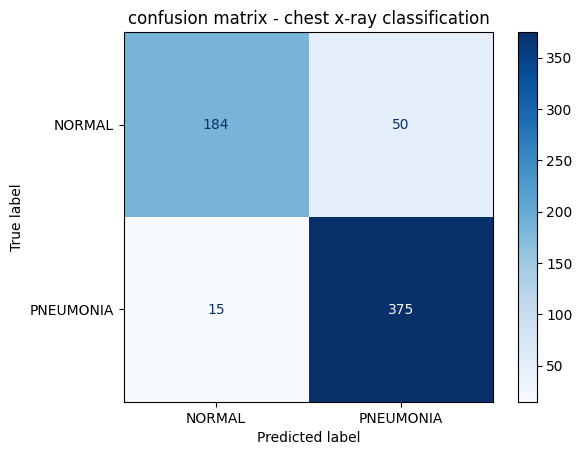

In [42]:
#confusion matrix
y_true = []
y_pred = []

for images,labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = (predictions>=.5).astype(int).flatten()

    y_pred.extend(predicted_labels)
    y_true.extend(labels.numpy().astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(6,6))
disp.plot(cmap='Blues',values_format='d')
plt.title('confusion matrix - chest x-ray classification')
plt.show()

In [44]:
#predictions for sample test images
sample_images = []
sample_labels = []

for image,label in test_ds.unbatch().take(10):
    sample_images.append(image.numpy())
    sample_labels.append(int(label.numpy()[0]))

sample_images = np.array(sample_images)

prediction_scores = model.predict(sample_images, verbose=0)

print('\npredictions vs real')
print('-'*70)

for i,score in enumerate(prediction_scores):
    predicted_label = int(score[0]>=.5)

    predicted_class = class_names[predicted_label]
    actual_class = class_names[sample_labels[i]]

    print(
        f'image {i + 1:02d} | '
        f'predicted: {predicted_class:10s} | '
        f'actual: {actual_class:10s} | '
        f'score: {float(score[0]) :.3f}')


predictions vs real
----------------------------------------------------------------------
image 01 | predicted: PNEUMONIA  | actual: PNEUMONIA  | score: 1.000
image 02 | predicted: PNEUMONIA  | actual: PNEUMONIA  | score: 1.000
image 03 | predicted: PNEUMONIA  | actual: PNEUMONIA  | score: 1.000
image 04 | predicted: PNEUMONIA  | actual: PNEUMONIA  | score: 0.996
image 05 | predicted: PNEUMONIA  | actual: PNEUMONIA  | score: 0.808
image 06 | predicted: PNEUMONIA  | actual: PNEUMONIA  | score: 1.000
image 07 | predicted: PNEUMONIA  | actual: PNEUMONIA  | score: 0.999
image 08 | predicted: PNEUMONIA  | actual: PNEUMONIA  | score: 0.793
image 09 | predicted: NORMAL     | actual: NORMAL     | score: 0.315
image 10 | predicted: PNEUMONIA  | actual: PNEUMONIA  | score: 0.996


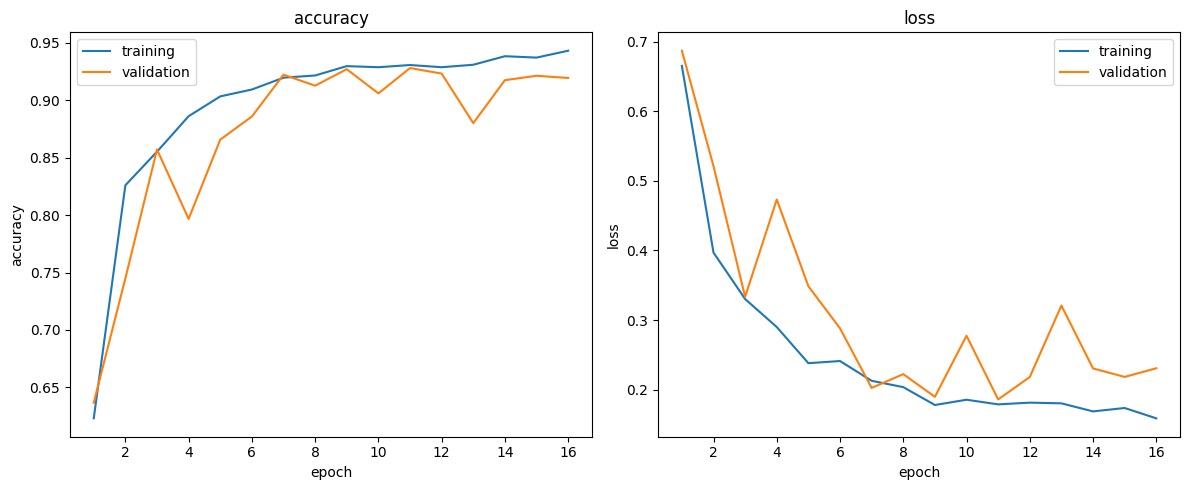

In [45]:
#plot training history
epochs_completed = range(1,len(history.history['loss'])+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_completed,history.history['accuracy'],label='training')
plt.plot(epochs_completed,history.history['val_accuracy'],label='validation')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_completed,history.history['loss'],label='training')
plt.plot(epochs_completed,history.history['val_loss'],label='validation')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('loss')
plt.legend()

plt.tight_layout()
plt.show()

Saving IM-0001-0001.jpeg to IM-0001-0001.jpeg
Saving IM-0003-0001.jpeg to IM-0003-0001.jpeg
Saving IM-0005-0001.jpeg to IM-0005-0001.jpeg
Saving person100_bacteria_478.jpeg to person100_bacteria_478.jpeg
Saving person100_bacteria_481.jpeg to person100_bacteria_481.jpeg


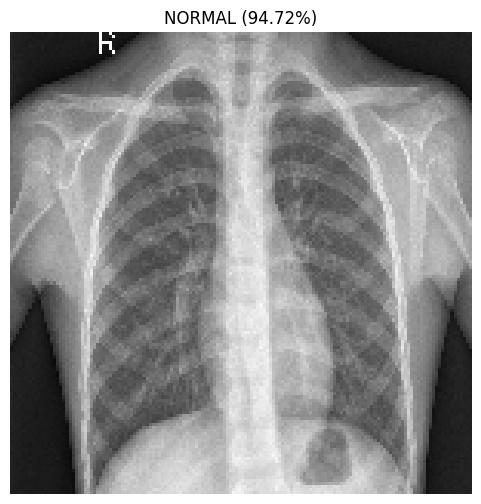

IM-0001-0001.jpeg → NORMAL (94.72%)


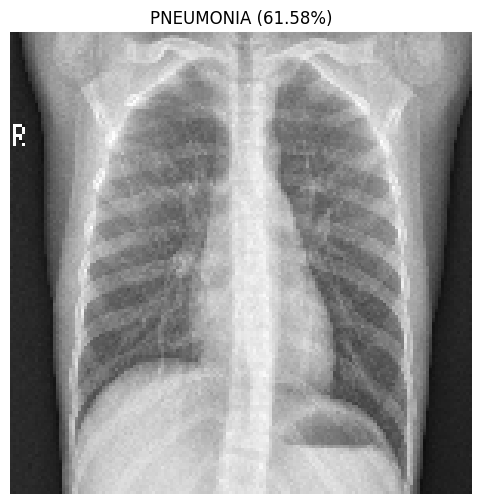

IM-0003-0001.jpeg → PNEUMONIA (61.58%)


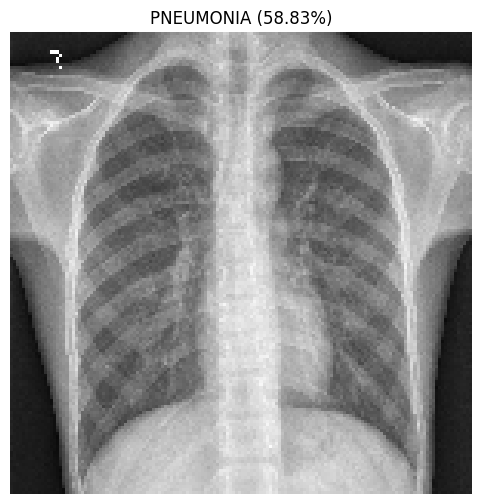

IM-0005-0001.jpeg → PNEUMONIA (58.83%)


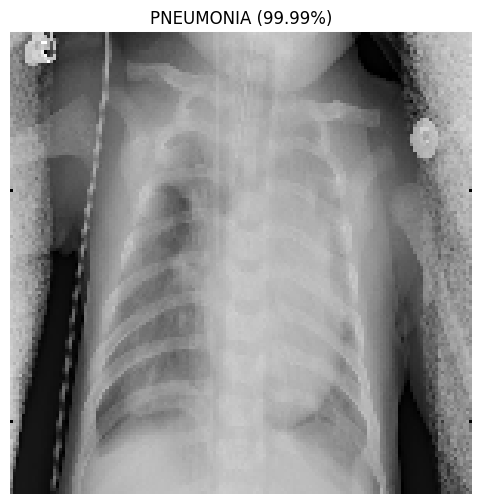

person100_bacteria_478.jpeg → PNEUMONIA (99.99%)


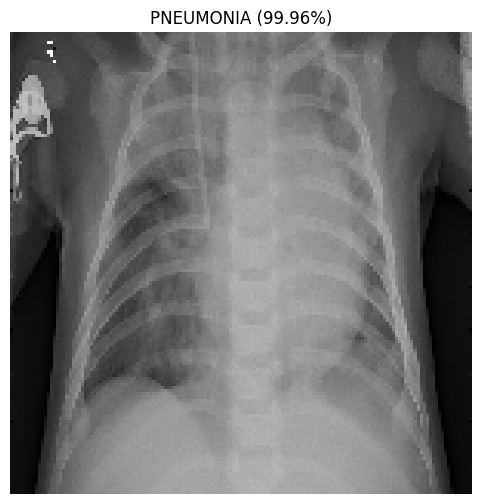

person100_bacteria_481.jpeg → PNEUMONIA (99.96%)


In [46]:
uploaded = files.upload()

if len(uploaded) < 5:
    print("Upload at least 5 images")

for filename in uploaded.keys():

    img = keras_image.load_img(filename, target_size=image_size)
    img_array = keras_image.img_to_array(img)

    display_img = img_array.astype("uint8")

    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]

    label = int(pred >= 0.5)
    class_name = class_names[label]

    confidence = (pred if label == 1 else 1 - pred) * 100

    plt.figure(figsize=(6, 6))
    plt.imshow(display_img)
    plt.axis("off")
    plt.title(f"{class_name.upper()} ({confidence:.2f}%)")
    plt.show()

    print(f"{filename} → {class_name} ({confidence:.2f}%)")